In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv('../data/activity_records.csv')
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            6362620 non-null  int64  
 1   type            6362620 non-null  str    
 2   amount          6362620 non-null  float64
 3   nameOrig        6362620 non-null  str    
 4   oldbalanceOrg   6362620 non-null  float64
 5   newbalanceOrig  6362620 non-null  float64
 6   nameDest        6362620 non-null  str    
 7   oldbalanceDest  6362620 non-null  float64
 8   newbalanceDest  6362620 non-null  float64
 9   isFraud         6362620 non-null  int64  
 10  isFlaggedFraud  6362620 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [4]:
df['type'].unique()

<StringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str

## Data Types to Fix
'type' is a string - which will need to be encoded during pre-processing in order to be used for the model.

## Columns to Drop
'nameOrig' can be dropped, as many accounts get defrauded. 
'nameDest' will also be dropped based on an assumption that since these transactions were already flagged as fraud, the specific destination accounts receiving the money would already be restricted and not reused.
'isFlaggedFraud' can be dropped since it's only correlated with 'amount' being greater than 200,000, and it's not useful for our model if we are including 'amount' as well.

In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Maximum steps being at 743 and translating to a timestamped hour - this dataset covers 31 days of activity. Since there's no specified calendar date for step 1, or hour of a day such as 1AM, we cannot analyze by those metrics.

Other analysis potential:

    Does a higher number of transactions in a given hour correlate with a higher percentage of *fraudulent* transactions?

    Plot fraudulent and all transactions over time (step).

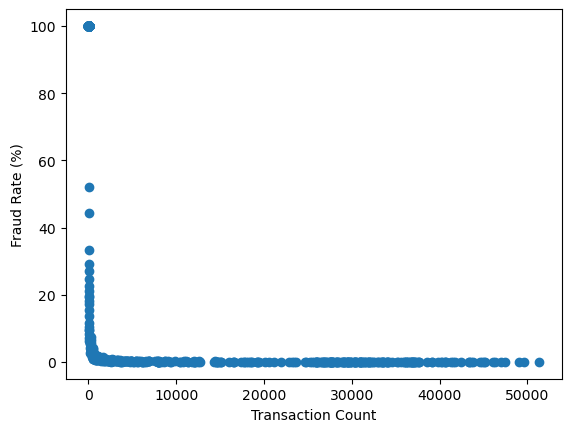

In [6]:
hourly_stats = df.groupby('step')['isFraud'].agg(
    fraud_percent=lambda x: x.mean() * 100,
    transaction_count='count'
)

plt.scatter(hourly_stats['transaction_count'], hourly_stats['fraud_percent'])
plt.xlabel('Transaction Count')
plt.ylabel('Fraud Rate (%)')
plt.show()

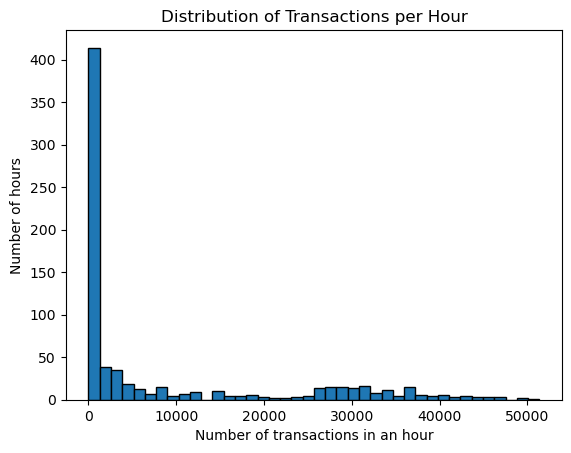

In [7]:
txns_per_hour = df['step'].value_counts()

plt.hist(txns_per_hour, bins=40, edgecolor='black')
plt.xlabel('Number of transactions in an hour')
plt.ylabel('Number of hours')
plt.title('Distribution of Transactions per Hour')
plt.show()

In [8]:
median_hourly_trans_count = hourly_stats['transaction_count'].median()
print(median_hourly_trans_count)

529.0


In [9]:
hourly_stats = df.groupby('step')['isFraud'].agg(
    fraud_percent=lambda x: x.mean() * 100,
    transaction_count='count'
)

# only keep hours with up to 5k transactions
filtered_stats = hourly_stats[hourly_stats['transaction_count'] <= median_hourly_transaction_count]

plt.scatter(filtered_stats['transaction_count'], filtered_stats['fraud_percent'])
plt.xlabel('Transaction Count')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate vs Transaction Count (hours with ≤5k transactions)')
plt.show()

NameError: name 'median_hourly_transaction_count' is not defined

Due to the small sample size for hours with less transaction counts, the higher fraud rate is misleading - one fraudulent case out of 2 transactions put fraud rate at 50%. At the same time, higher transaction counts do not show a correlation with higher fraud rates.

In [ ]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [ ]:
# check for duplicate rows
df[df.duplicated()]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud


In [ ]:
print(df.groupby("type")["isFraud"].mean())


type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64


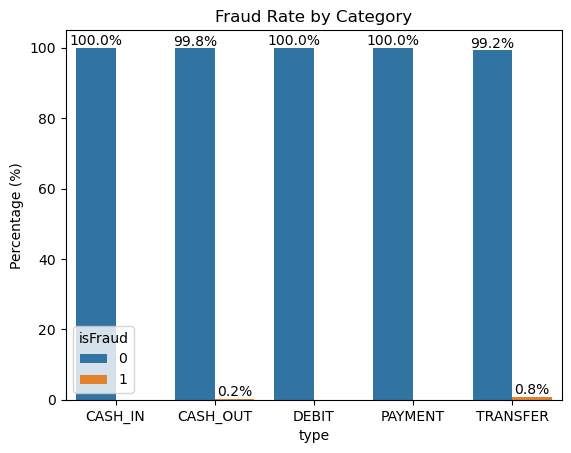

In [ ]:
prop_fraud_of_type = (df.groupby('type')['isFraud']
                      .value_counts(normalize=True)
                      .mul(100)
                      .rename('percent')
                      .reset_index())

ax = sns.barplot(data=prop_fraud_of_type, x='type', y='percent', hue='isFraud')
ax.set_ylabel('Percentage (%)')
ax.set_title('Fraud Rate by Category')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()


In [ ]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

TRANSFER have the highest rate of being fraudulent, even though they do not make up a majority of transactions. This column will serve well as a feature in the model. Make is_cash_out and is_transfer their own binary columns as features.

In [ ]:
# How many transactions out of all are fraudulent?
fraud_count = df['isFraud'].sum()
total_count = len(df)
fraud_percent = fraud_count / total_count * 100

print("Fraud Count:", fraud_count)
print("Total Count:", total_count)
print("Percent Fraud:", fraud_percent)

Fraud Count: 8213
Total Count: 6362620
Percent Fraud: 0.12908204481801522


High class imbalance of the output variable will necessitate a more thoughtful selection of the data to be used for training. 

Metrics that'll also be vital to use when evaluating the model are:
Recall - what percent of fraud did the model catch?
Precision - what percent of transactions flagged as fraud are actually fraud?
F1-score - how well does the model balance recall and precision?
Confusion Matrix - shows the actual predictions made.


In [ ]:
df.groupby('isFraud')['amount'].median()

isFraud
0     74684.72
1    441423.44
Name: amount, dtype: float64

Fraudulent transactions included much higher amounts of money.

In [ ]:
unique_orig_names = df['nameOrig'].nunique()
all_orig_names = len(df['nameOrig'])

print(unique_orig_names)
print(all_orig_names)

6353307
6362620


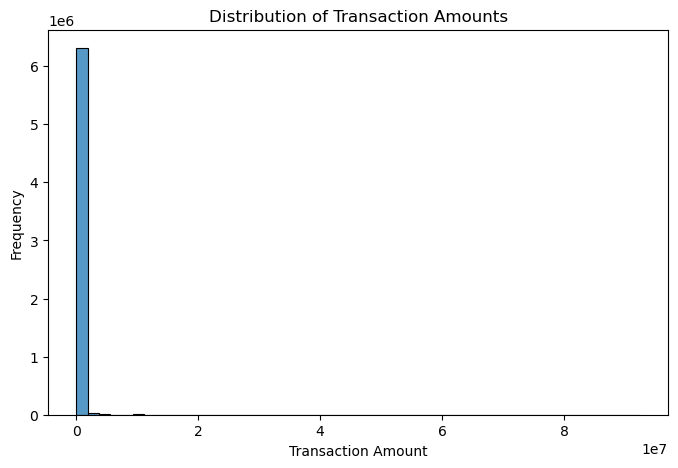

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['amount'], bins=50)
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts')
plt.show()

The distribution for transaction amounts is heavily rightly skewed.

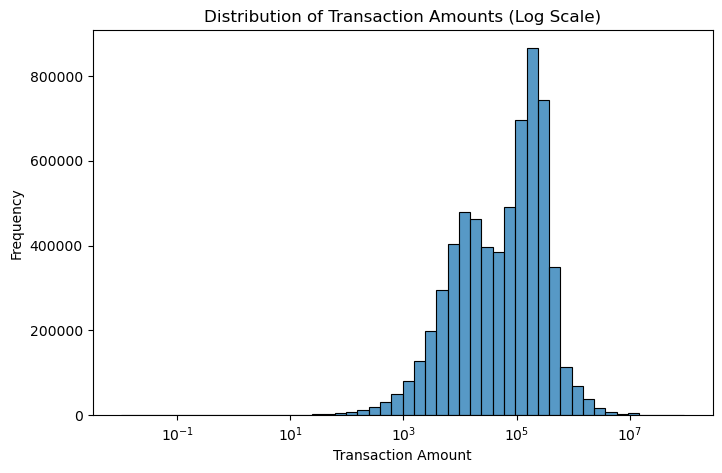

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['amount'], bins=50, log_scale=True)
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts (Log Scale)')
plt.show()

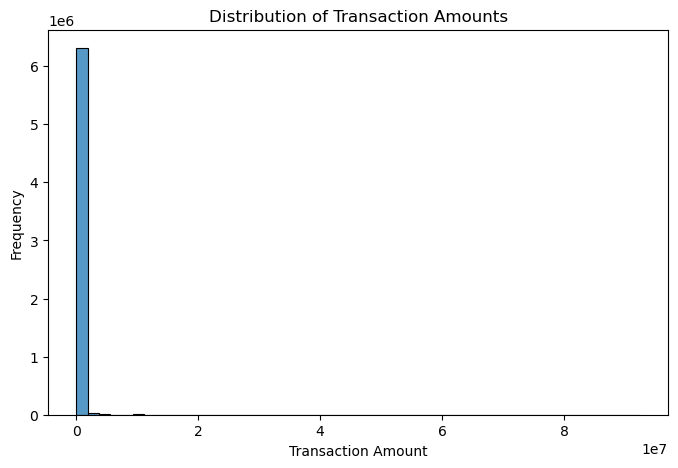

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['amount'], bins=50)
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts')
plt.show()

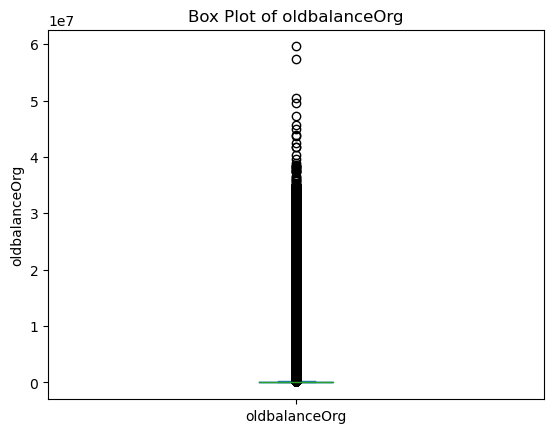

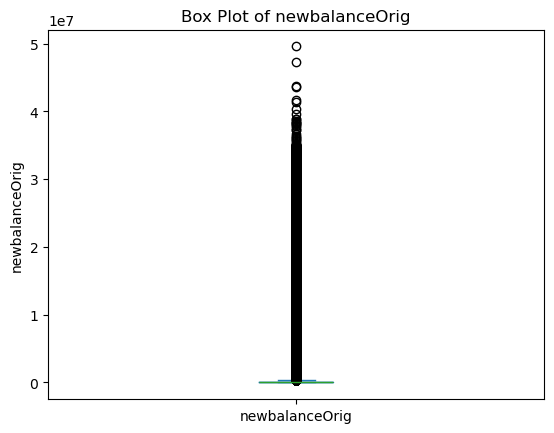

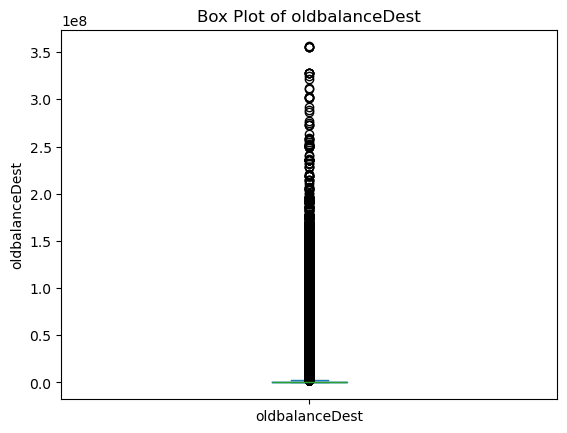

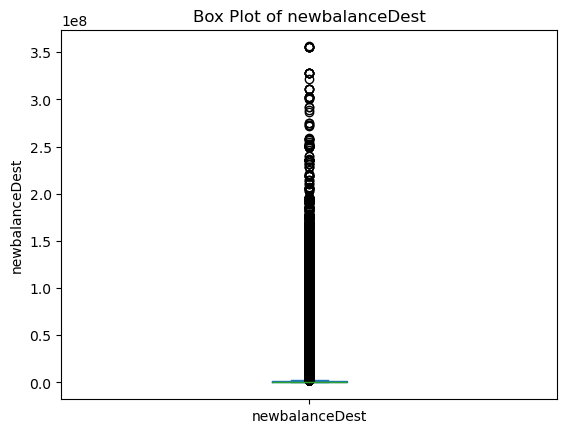

In [ ]:
num_columns = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for col in num_columns:
    df[col].plot(kind='box')
    plt.ylabel(col)
    plt.title(f'Box Plot of {col}')
    plt.show()

There's extreme right skews in account data, making the typical distributions hard to interpret at first glance. Adding a log scale for the y axis with help see the distribution of where most of the data actually lies.

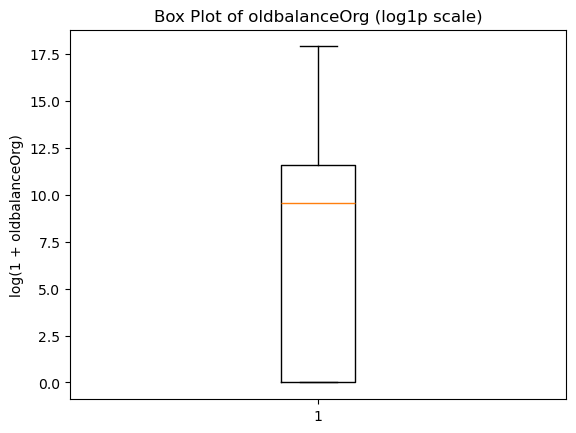

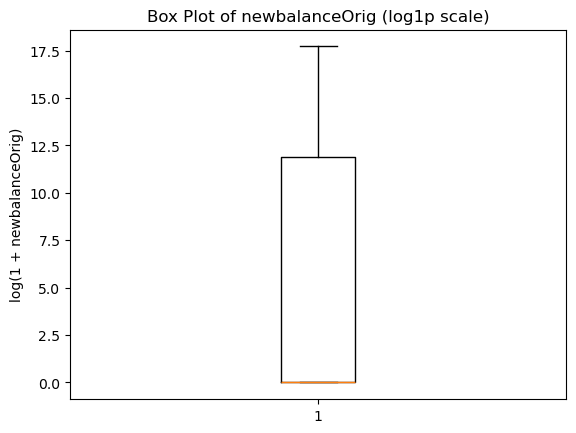

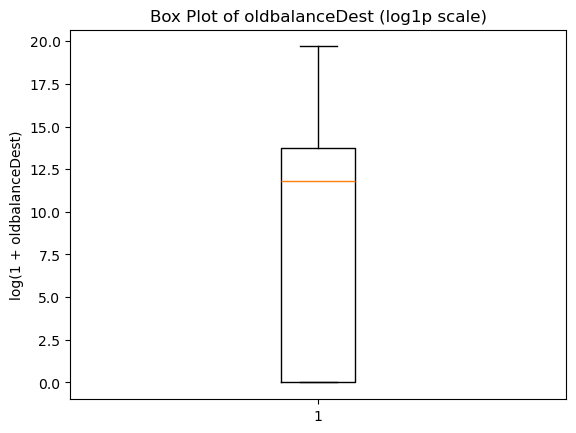

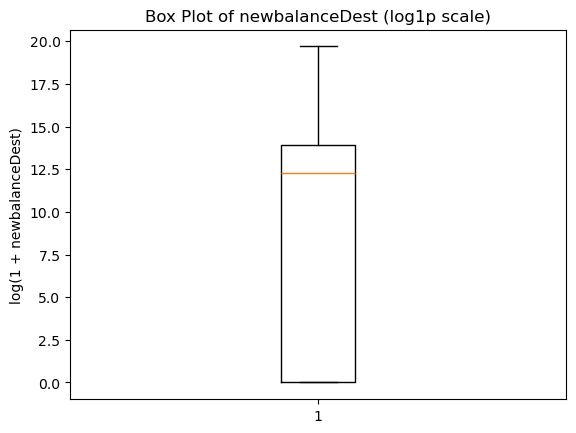

In [ ]:
for col in num_columns:

    plt.boxplot(np.log1p(df[col]))
    plt.ylabel(f'log(1 + {col})')
    plt.title(f'Box Plot of {col} (log1p scale)')
    plt.show()

Pre-transaction balances of origin accounts consist of at least 25% at 0 currency, and half reaching to ~e^9.5 (~13k in currency). After the transaction, at least half of the origin accounts empty to 0.

Meanwhile, destination accounts pre and post transfer remain very similar, with the median balance only slightly slightly post transaction.

In [ ]:
# How does the presence of fraud correlate with new origin account balances?
df.groupby('isFraud')['newbalanceOrig'].std()

isFraud
0    2.924987e+06
1    1.965666e+06
Name: newbalanceOrig, dtype: float64

Fraudulent transactions show less variation in the resulting bank balance amount, which falls in line with intuition since fraud often results in drained bank accounts to 0 as opposed to non-fraudulent transaction that have much more variation in post transaction balances.

In [ ]:
df.groupby('isFraud')['newbalanceOrig'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,855970.228109,2.924987e+06,0.0,0.0,0.0,144730.74,43686616.33
1,8213.0,192392.631836,1.965666e+06,0.0,0.0,0.0,0.00,49585040.37


Up to 75% of fraudulent transactions end with the origin account balance being at 0 - which occurs significantly less often with non fraudulent transactions.

Create a new feature: 'new_balance_orig_is_0'

In [ ]:
# A sanity check to compare proportion of 0 for fraud vs non fraud:

df.groupby('isFraud')['newbalanceOrig'].apply(lambda x: (x == 0).mean())

isFraud
0    0.566774
1    0.980519
Name: newbalanceOrig, dtype: float64

98.1% of fraudulent transactions end with a zero origin balance, confirming that engineering a feature that states whether newbalanceOrig is 0 would be a valuable predictor for the model.

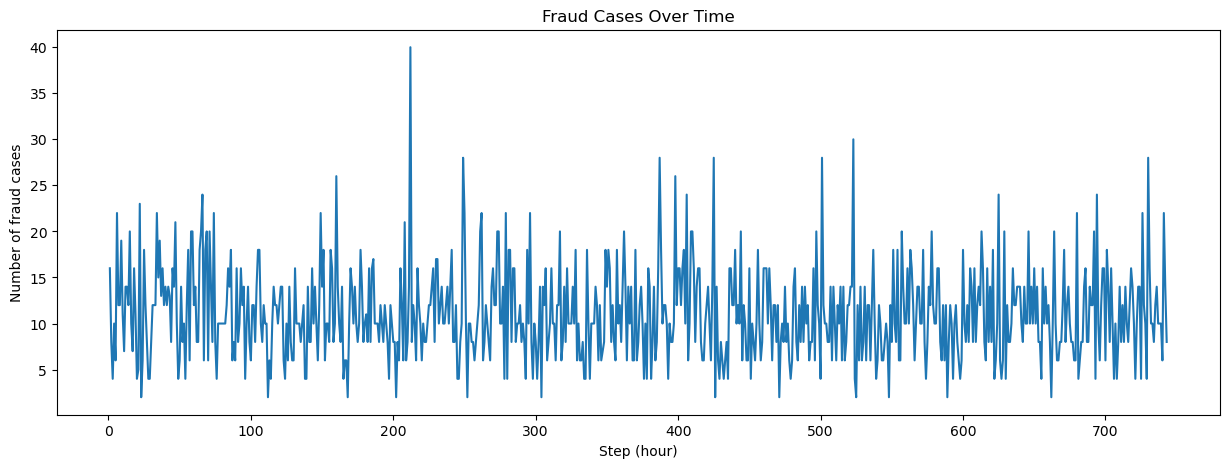

In [ ]:
# plot step vs cases of fraud over time

fraud_by_step = df[df['isFraud'] == 1].groupby('step').size()

plt.figure(figsize=(15, 5))
plt.plot(fraud_by_step.index, fraud_by_step.values)
plt.xlabel('Step (hour)')
plt.ylabel('Number of fraud cases')
plt.title('Fraud Cases Over Time')
plt.show()

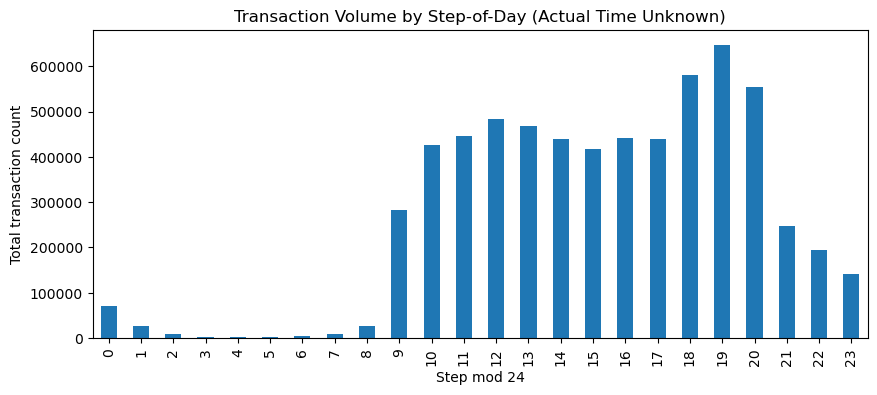

In [ ]:
   df.groupby(df['step'] % 24)['step'].count().plot(kind='bar', figsize=(10,4))
   plt.xlabel('Step mod 24')
   plt.ylabel('Total transaction count')
   plt.title('Transaction Volume by Step-of-Day (Actual Time Unknown)')
   plt.show()

There is a cyclical 24hr nature to the volume of overall transactions.

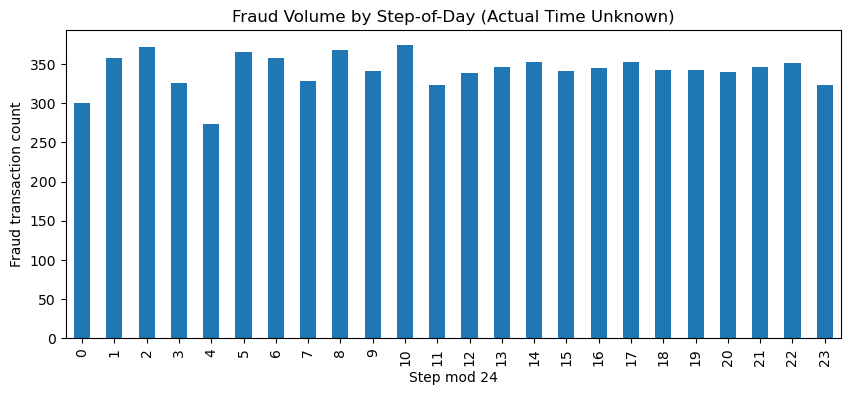

In [ ]:
df[df['isFraud'] == 1].groupby(df['step'] % 24)['step'].count().plot(kind='bar', figsize=(10,4))
plt.xlabel('Step mod 24')
plt.ylabel('Fraud transaction count')
plt.title('Fraud Volume by Step-of-Day (Actual Time Unknown)')
plt.show()

Unlike overall transactions, fraudulent ones do not fluctuate throughout a 24 hour cycle.

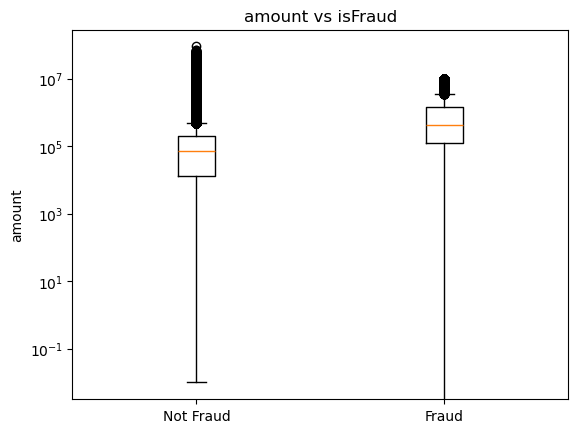

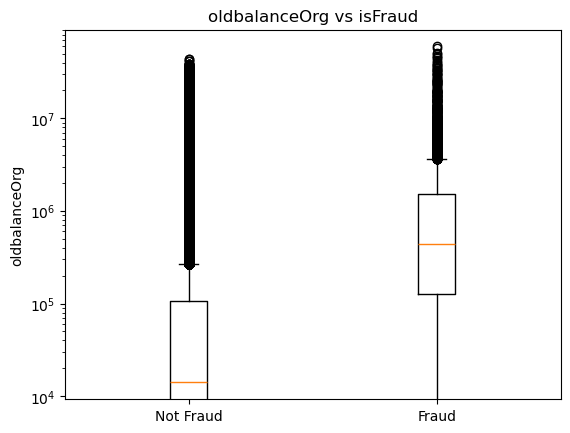

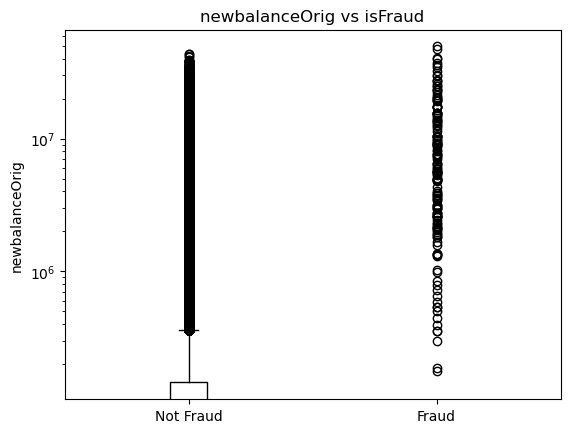

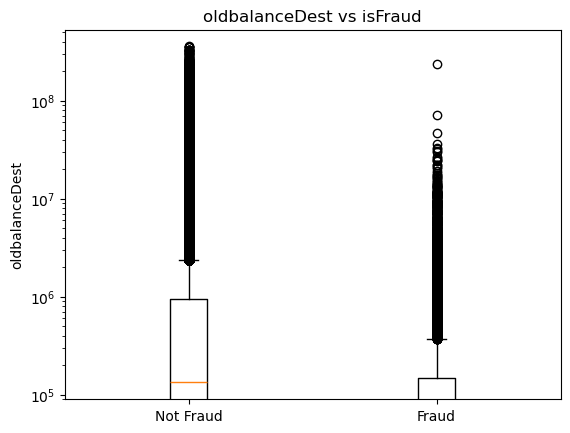

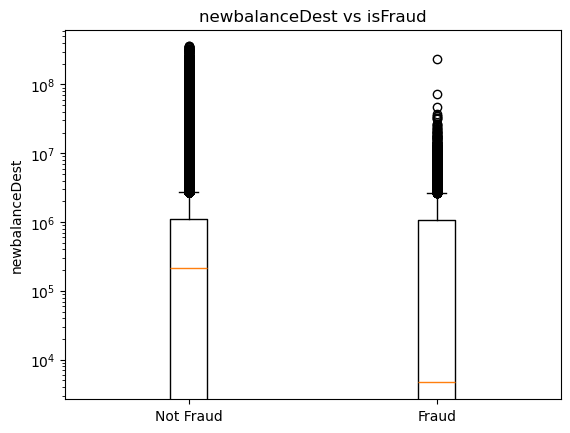

In [10]:
# Check more variables for distributions against the isFraud column

cols = [c for c in df.columns if c not in ["step", "type", "nameOrig", "nameDest", "isFraud", "isFlaggedFraud"]]

for col in cols:
    fraud = df[df['isFraud'] == 1][col]
    not_fraud = df[df['isFraud'] == 0][col]

    plt.boxplot([not_fraud, fraud], tick_labels=['Not Fraud', 'Fraud'])
    plt.yscale('log')
    plt.ylabel(col)
    plt.title(f"{col} vs isFraud")
    plt.show()


'Amount', 'oldbalanceOrg', 'newbalanceOrig' and 'oldbalanceDest' have noticeable differences between fraudulent and non fraudulent transactions, often with ~50-75% of amounts and account balances being higher or lower by comparison.

## Correlation Matrix

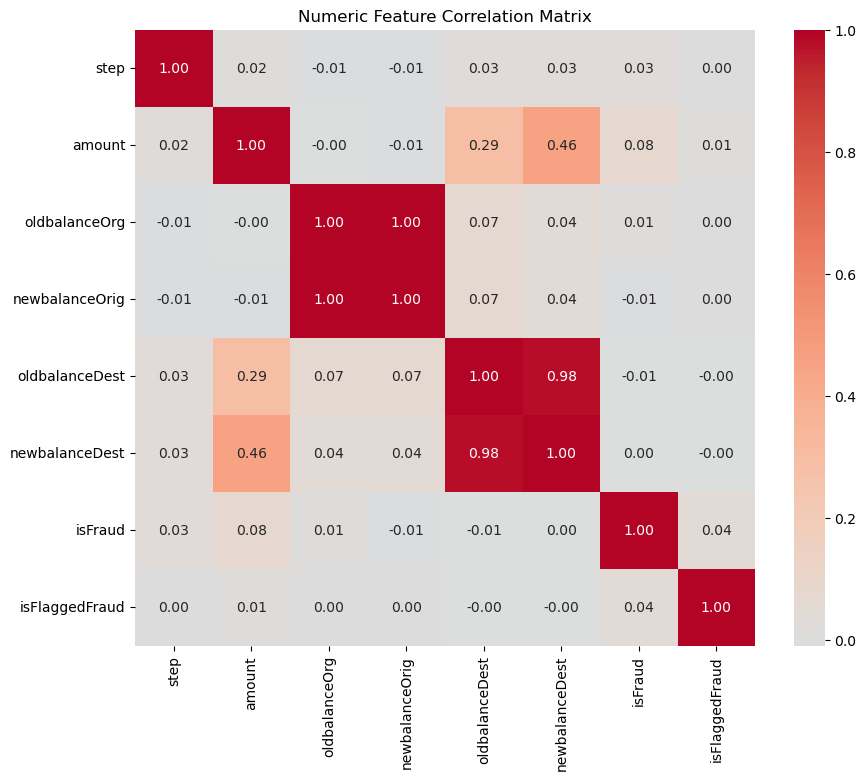

In [ ]:
# Generated by Claude
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr(method='pearson') 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric Feature Correlation Matrix')
plt.show()

While a random forest model can work with correlated variables, for the sake of desiring interpretation of the most impactful variable, only those without high correlation to each other will be used in this model.

While 'oldbalanceDest' has noticeable differences between fraud and non fraud transactions, it has high correlation to 'amount', which will be a feature in the model along side 'oldbalanceOrg', due to the fact that they both have significant differences in data distributions when comparing fraudulent and non fraudulent transactions for each. Since I'm including 'oldbalanceOrg' and it is perfectly correlated with 'newbalanceOrig', I wont include the latter. There will already be a new feature created from 'newbalanceOrig' which identifies the most important fraud predictor from that variable - whether the new balance for the original account is 0. 

'newbalanceDest' is also very correlated with 'amount' so it will be dropped - as the other variables showed more difference between fraud/non-fraud outcomes.

In [12]:
df['trans_perc'] = df['amount']/df['oldbalanceOrg']
df['trans_perc'].head(5)

# 'trans_perc' = amount/oldbalanceOrig (accounts that are fraudulent may more often drain the account completely,
# meaning the amount transacted would more commonly be 100% of the original account's starting balance.)

0    0.057834
1    0.087735
2    1.000000
3    1.000000
4    0.280795
Name: trans_perc, dtype: float64

In [ ]:
df.groupby('isFraud')['trans_perc'].describe()

e:\Miniconda\envs\da\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
e:\Miniconda\envs\da\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
e:\Miniconda\envs\da\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,inf,NaN,1.765481e-08,0.233414,6.516319,NaN,inf
1,8197.0,inf,NaN,3.837324e-02,1.000000,1.000000,1.0,inf


Since there are old balances for original accounts that start at 0, dividing amount by 0 produced 'inf', infinite values for mean and max. This is handled below, and a separate column is created to flag rows that had a 0 transaction percent simply due to not having money in the account.

In [ ]:
df['trans_perc'] = df['amount'] / df['oldbalanceOrg'].replace(0, np.nan)


print("Inf count:", np.isinf(df['trans_perc']).sum())  
print("NaN count:", df['trans_perc'].isna().sum())      

Inf count: 0
NaN count: 2102449


In [ ]:
df['had_zero_orig_balance'] = (df['oldbalanceOrg'] == 0).astype(int)
df['trans_perc'] = df['trans_perc'].fillna(0)

In [ ]:
print(df.groupby('isFraud')['trans_perc'].describe())

             count       mean          std  min  25%       50%       75%  \
isFraud                                                                    
0        6354407.0  81.817792  3397.897923  0.0  0.0  0.076139  2.228795   
1           8213.0   0.993779     0.390756  0.0  1.0  1.000000  1.000000   

                  max  
isFraud                
0        3.925476e+06  
1        2.952662e+01  


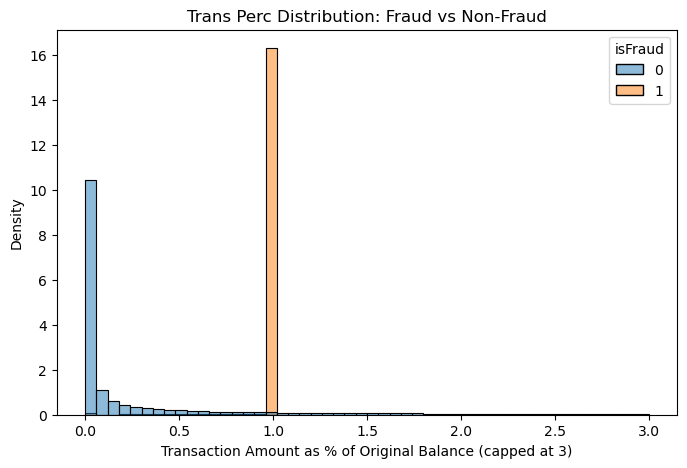

In [ ]:
# Used Claude to generate
plt.figure(figsize=(8, 5))
sns.histplot(data=df[df['trans_perc'] <= 3], x='trans_perc', hue='isFraud', 
             bins=50, stat='density', common_norm=False)
plt.xlabel('Transaction Amount as % of Original Balance (capped at 3)')
plt.title('Trans Perc Distribution: Fraud vs Non-Fraud')
plt.show()

Nearly all fraudulent transactions drained the account of it's full starting balance, meaning 'trans_perc' will be an excellent predictive feature.

In [ ]:
print(df.groupby('had_zero_orig_balance')['isFraud'].describe())

                           count      mean       std  min  25%  50%  75%  max
had_zero_orig_balance                                                        
0                      4260171.0  0.001918  0.043756  0.0  0.0  0.0  0.0  1.0
1                      2102449.0  0.000020  0.004416  0.0  0.0  0.0  0.0  1.0


Non-fraudulent transactions had a starting original balance of 0 at an average rate of 0.19%- fraudulent at a rate of 0.002%, meaning fraud occurred significantly less often if the starting balance was 0. Transactions with money in the account before a transaction were fraudulent 95x more often. 

An engineered feature 'had_zero_orig_balance' would have real signal.